In [2]:
from pathlib import Path

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import cv2

from skimage.feature import hog, canny
from skimage import data, exposure
from skimage.io import imread
from skimage.util import crop, invert, img_as_ubyte

from sklearn.cluster import spectral_clustering
from sklearn.feature_extraction import image as skl_image

In [2]:
# Ingest image
img_path = Path("C:/Users/werty/Downloads/06_01_017186A_image_access_full/3_06_01_017186C_image_access_full.jpg")
image: np.ndarray = imread(img_path, as_gray=True)
image = crop(image, ((500, 1250), (600, 780)))

In [3]:
image = exposure.adjust_sigmoid(image, cutoff=0.5, gain=10)

In [4]:
# Rescale intensity
v_min, v_max = np.percentile(image, (4, 96))
print(f"v_min: {v_min}, v_max: {v_max}")
image = exposure.rescale_intensity(image, in_range=(v_min, v_max))
#image = invert(image)
# Set all pixels below a certain threshold to black, and all pixels above a certain threshold to white
low_threshold = 0.15
image[image < low_threshold] = 0
high_threshold = 0.95
image[image > high_threshold] = 1

v_min: 0.1795267828894612, v_max: 0.9642762051515212


In [5]:
# Make values range from 0 to 255 and convert to uint8
# Required for efficient image processing in OpenCV and scikit-image
image = img_as_ubyte(image)

canny_image = canny(image, sigma=3.0)
canny_image = img_as_ubyte(canny_image)
_, canny_image = cv2.threshold(canny_image, 127, 255, cv2.THRESH_BINARY)

scaling = np.copy(canny_image)
scaling[scaling > 0] = 1

composite_image = np.multiply(image, scaling)
del scaling

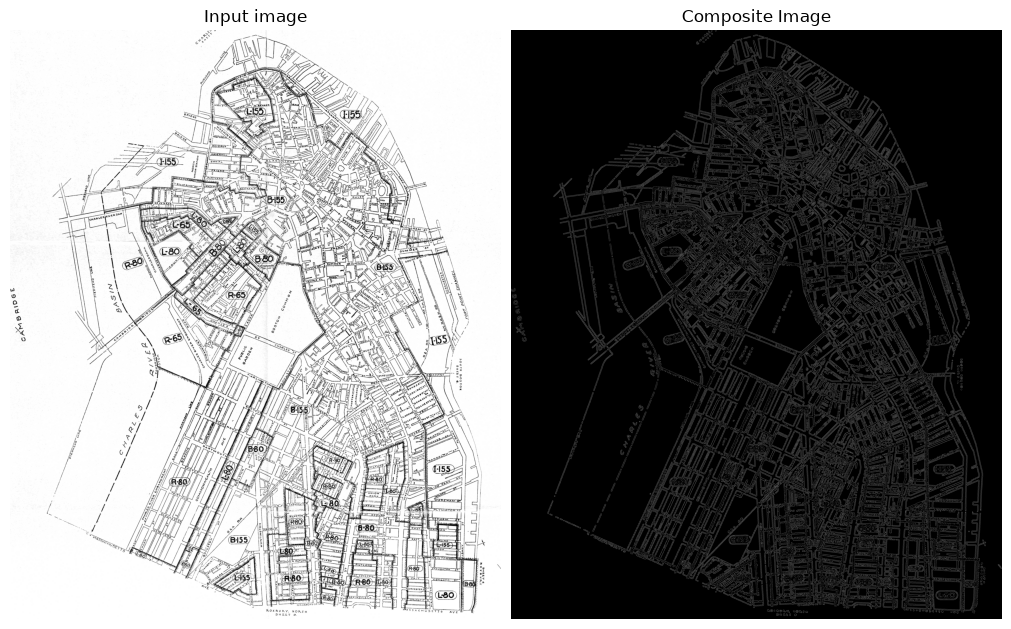

In [7]:
fig, (ax1, ax2) =  plt.subplots(1, 2, figsize=(10, 8), layout='compressed')

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

ax2.axis('off')
ax2.imshow(composite_image, cmap=plt.cm.gray)
ax2.set_title('Composite Image')

plt.show()

In [ ]:
gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=1)
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

In [ ]:
fig, (ax1, ax2) =  plt.subplots(1, 2, figsize=(12, 10), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(gx)

ax2.axis('off')
ax2.imshow(gy)

plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(mag)
plt.show()

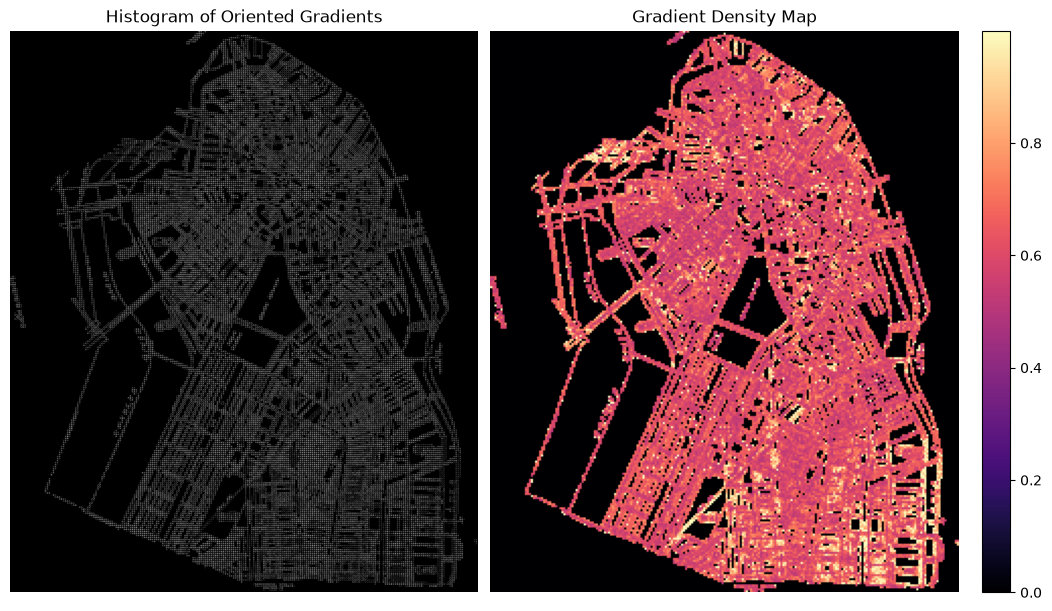

In [6]:
fd, hog_image = hog(
    composite_image,
    orientations=8,
    pixels_per_cell=(16, 16),
    cells_per_block=(1, 1),
    visualize=True,
    feature_vector=False
)

# Norm of the histogram of oriented gradients features
limited_histogram = np.squeeze(fd)
gradient_density = np.linalg.norm(limited_histogram, ord=8, axis=-1)
del limited_histogram

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), layout='compressed')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax1.axis('off')
hog_map = ax1.imshow(hog_image_rescaled, cmap=plt.cm.gray, aspect='equal')
ax1.set_title('Histogram of Oriented Gradients')

ax2.axis('off')
gradient_density_map = ax2.imshow(gradient_density, cmap='magma', aspect='equal')
ax2.set_title('Gradient Density Map')
fig.colorbar(gradient_density_map, ax=ax2)

plt.show()

In [ ]:
manipulated_image = np.copy(image)

# Apply Harris corner detection to the original image
dst = cv2.cornerHarris(image, blockSize=2, ksize=3, k=0.04)

# Dilate the corner image to enhance corner points
dst_dilated = cv2.dilate(dst, None)

# Threshold for optimal value (adjust based on image)
manipulated_image[dst > 0.01 * dst.max()] = [0, 0, 255]

cv2.imshow('Harris Corners', manipulated_image)
cv2.waitKey(0)